In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# Caminhos padrões para os arquivos e pastas
caminho_raw = "../dados/raw/"
caminho_gold = "../dados/gold/"

os.makedirs(caminho_gold, exist_ok=True)

In [3]:
# Carregando dataframe consolidado do site Reclame Aqui
df_reclamacao = pd.read_parquet(os.path.join(caminho_raw,'reclamacoes_master.parquet'))

col_str = ['banco','titulo']

for col in col_str:
    df_reclamacao[col] = df_reclamacao[col].astype('string')

df_reclamacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   banco   465 non-null    string
 1   titulo  465 non-null    string
 2   link    465 non-null    object
 3   pagina  465 non-null    int64 
 4   alerta  465 non-null    bool  
dtypes: bool(1), int64(1), object(1), string(2)
memory usage: 15.1+ KB


In [4]:
# 1. Definições
termos_liquidez = (
    'saque|travado|bloqueio|bloqueada|preso|não cai|não caiu|'
    'retido|retenção|segurou|não libera|não consigo resgatar|'
    'resgate|vencimento|cdb|lci|lca|dinheiro preso|conta zerada|'
    'sumiu o saldo|desapareceu o dinheiro|pix em processamento|'
    'devolve meu dinheiro|apropriação'
)
termos_integridade = (
    'golpe|indevid|descontou|desconto|não fiz|não contratei|'
    'não autorizei|falsidade|fraude|clonado|vazamento|desconhecida|'
    'juros abusivos|consignado|rmc|reserva de margem|averbação|averbou|'
    'portabilidade|enganosa|mentira|contrato falso|assinatura falsa|'
    'seguro prestamista|venda casada'
)
termos_ruido = (
    'lento|demora|horrível|ruim|péssimo|fila|espera|'
    'atendimento|atendente|chat|robô|bot|telefone|sac|ouvidoria|'
    'desligam|não atendem|app|aplicativo|bug|erro|travando|'
    'fora do ar|instabilidade|token|senha|biometria|facial|'
    'cadastro|abrir conta|encerrar conta|cartão não chegou|limite'
)

# 2. Criamos as condições (Hierarquia)
condicoes = [

    # Nível 1: Crítico
    df_reclamacao['titulo'].str.contains(termos_liquidez, case=False, na=False),
    
    # Nível 2: Médio
    df_reclamacao['titulo'].str.contains(termos_integridade, case=False, na=False),
    
    # Nível 3: Baixo
    df_reclamacao['titulo'].str.contains(termos_ruido, case=False, na=False)
]

# 3. Criamos os Rótulos (Na mesma ordem)
escolhas = ['Liquidez', 'Integridade', 'Ruído']

# 4. Direcionamento por condição
# Ele olha a primeira condição. Se for True, atribui o valor. 
df_reclamacao['categoria_risco'] = np.select(condicoes, escolhas, default='Outros')


In [5]:
# --- Análise ---
print(df_reclamacao['categoria_risco'].value_counts())

# Calculo da % do índice crítico
total = len(df_reclamacao)
qtd_critico = len(df_reclamacao[df_reclamacao['categoria_risco'] == 'Liquidez'])

print(f"\n🔥 Índice crítico: {(qtd_critico/total)*100:.1f} %")

categoria_risco
Integridade    209
Outros         133
Ruído           91
Liquidez        32
Name: count, dtype: int64

🔥 Índice crítico: 6.9 %


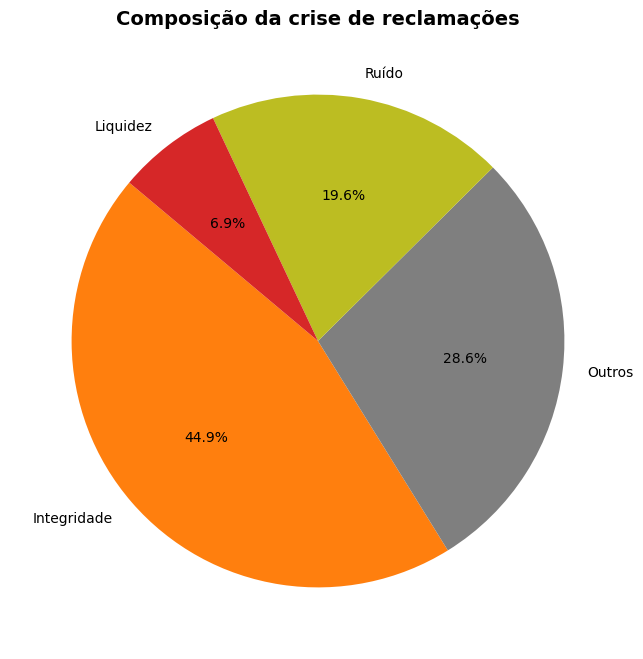

In [26]:
plt.figure(figsize=(8, 8))

# Conta os valores
dados_composicao = df_reclamacao['categoria_risco'].value_counts()

cores = {'Liquidez' : '#d62728','Integridade' : '#ff7f0e','Ruído' : '#bcbd22','Outros' : '#7f7f7f'}

# Lista de cores ordenada conforme os dados
lista_cores = [cores[label] for label in dados_composicao.index]

# Plota
plt.pie(
    dados_composicao, 
    labels=dados_composicao.index, 
    autopct='%1.1f%%', 
    colors=lista_cores,
    startangle=140
    )

plt.title('Composição da crise de reclamações', fontsize=14, fontweight='bold')
plt.show()

C:\Users\Thiag\AppData\Local\Temp\ipykernel_11228\166745081.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_palavras, x='Frequência', y='Palavra', palette='Reds_r')


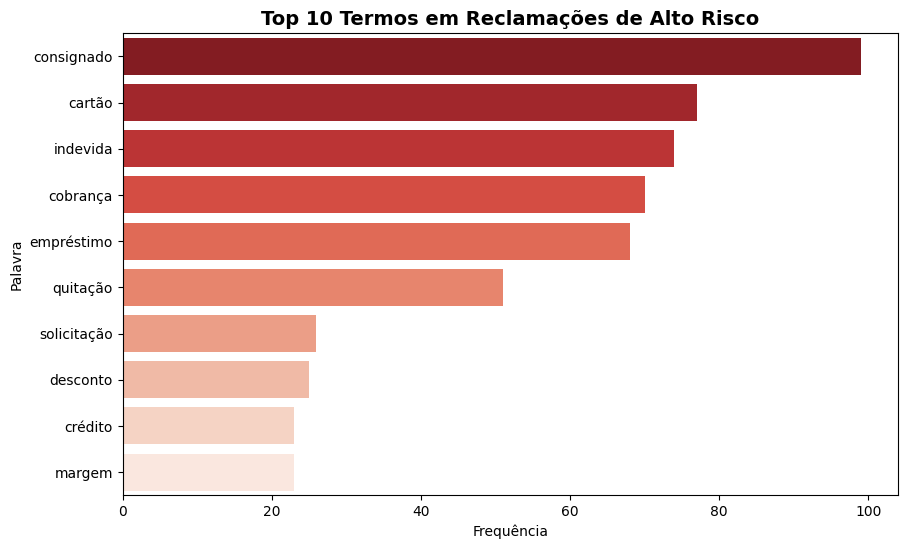

In [9]:
# Filtra só o que é crítico (Liquidez + Integridade)
df_perigo = df_reclamacao[df_reclamacao['categoria_risco'].isin(['Liquidez', 'Integridade',])]

# Junta todo o texto-
todos_titulos = " ".join(df_perigo['titulo'].str.lower())

# Lista de palavras manuais para remover
stopwords = ['de', 'o', 'a', 'e', 'do', 'da', 'em', 'para', 'com', 'não', 'que', 'um', 'uma', 'banco', 'master', 'reclamação', 'meu', 'minha', 'após','dificuldade']
palavras = [p for p in todos_titulos.split() if p not in stopwords and len(p) > 4]

# Conta as top 10
contagem = Counter(palavras).most_common(10)
df_palavras = pd.DataFrame(contagem, columns=['Palavra', 'Frequência'])


plt.figure(figsize=(10, 6))
sns.barplot(data=df_palavras, x='Frequência', y='Palavra', palette='Reds_r')
plt.title('Top 10 Termos em Reclamações de Alto Risco', fontsize=14, fontweight='bold')
plt.show()